# M21 · Diffusion & Visual Generation — ✍️ Toy Example, Step by Tiny Step

**Companion to lesson M21. Written for someone new to ML.**

Diffusion models learn to **generate** by learning to **denoise**. Instead of downloading real
images or big models, this notebook uses a tiny synthetic 2D "picture world": two colored clouds of
points. Every major idea gets a **Toy example**, every code cell prints the numbers it computes, and
nearly every idea has a picture. Run top to bottom; nothing needs the internet.

**What you'll do:**
- Add Gaussian noise until data becomes nearly pure noise (**forward / diffusion process**).
- Train a tiny MLP to predict the noise (**epsilon prediction**).
- Start from noise and repeatedly denoise to make new samples (**reverse / sampling process**).
- Add class labels (**conditioning**) and adjust label strength (**classifier-free guidance**).
- Map the toy to real text-to-image and video systems.

## Big idea · Toy example overview

A **forward process** (also called the **diffusion process**) gradually corrupts data by adding
random Gaussian noise. A **reverse process** (also called the **denoising process**) learns the
opposite direction: start from noise, remove a little noise at a time, and end with a new sample.

Pipeline:

`data point → add a little noise → add more noise → pure-ish noise`

then, after training:

`pure noise → denoise → denoise → generated data point`

**Good for:** generating images, audio, video, molecules, or any data where "start random, refine
step by step" is useful.

**Watch out for:** diffusion is iterative, so sampling can be slower than one-shot generators; the
denoiser must be trained carefully because tiny errors happen many times.

## Step 0 · Setup

Import NumPy (arrays), scikit-learn (a tiny MLP), and Matplotlib (pictures). Fix the **seed** so the
printed numbers are reproducible, and define a tiny `log()` helper.

In [3]:
import warnings
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)
np.random.seed(0)
plt.rcParams["figure.figsize"] = (6, 4)

def log(label, value):
    print(f"[{label}] {value}")

def equal_axes(ax):
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.2)

log("setup", "tools ready — NumPy + scikit-learn MLPRegressor + Matplotlib, seed fixed to 0")

[setup] tools ready — NumPy + scikit-learn MLPRegressor + Matplotlib, seed fixed to 0


## Big idea · Toy example picture

Before doing math, here is the whole chain as a tiny drawing: the left side destroys structure by
adding noise; the right side learns to rebuild structure by denoising.

[pipeline step 1] forward: data -> noisy data -> almost pure noise
[pipeline step 2] reverse: pure noise -> denoise repeatedly -> generated data


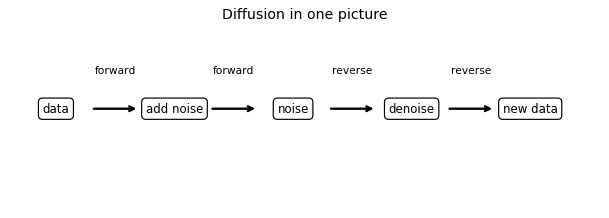

In [5]:
log("pipeline step 1", "forward: data -> noisy data -> almost pure noise")
log("pipeline step 2", "reverse: pure noise -> denoise repeatedly -> generated data")

fig, ax = plt.subplots(figsize=(9, 2.8))
ax.axis("off")
boxes = [("data", 0.08), ("add noise", 0.28), ("noise", 0.48), ("denoise", 0.68), ("new data", 0.88)]
for text, x in boxes:
    ax.text(x, 0.55, text, ha="center", va="center",
            bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="black"))
for x0, x1, label in [(0.14, 0.22, "forward"), (0.34, 0.42, "forward"),
                      (0.54, 0.62, "reverse"), (0.74, 0.82, "reverse")]:
    ax.annotate("", xy=(x1, 0.55), xytext=(x0, 0.55), arrowprops=dict(arrowstyle="->", lw=2))
    ax.text((x0+x1)/2, 0.74, label, ha="center", fontsize=9)
ax.set_title("Diffusion in one picture")
plt.show()

---
# Part A · Our tiny visual world

## Toy example · two labeled 2D blobs as fake "images"

Real image models learn from millions of images. Here, each "image" is just a 2D point. The two
classes are two clouds: class 0 on the left and class 1 on the right.

**Good for:** seeing every step in 2D without heavy models.

**Watch out for:** this is not photo-realistic generation; it is the same *mechanism* on a toy
distribution.

[data shape] (280, 2)
[class counts] {0: 140, 1: 140}
[overall mean] [-0.028, -0.002]
[overall std] [2.017, 0.363]
[first 3 points] [[-1.383, -0.138], [-1.657, 0.377], [-1.346, -0.524]]


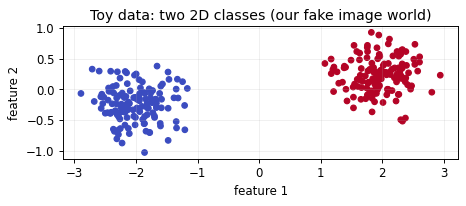

In [7]:
n_per_class = 140
class0 = np.random.normal(loc=[-2.0, -0.25], scale=[0.35, 0.28], size=(n_per_class, 2))
class1 = np.random.normal(loc=[ 2.0,  0.25], scale=[0.35, 0.28], size=(n_per_class, 2))
X = np.vstack([class0, class1])
y = np.array([0]*n_per_class + [1]*n_per_class)

log("data shape", X.shape)
log("class counts", {0: int((y == 0).sum()), 1: int((y == 1).sum())})
log("overall mean", np.round(X.mean(axis=0), 3).tolist())
log("overall std", np.round(X.std(axis=0), 3).tolist())
log("first 3 points", np.round(X[:3], 3).tolist())

plt.scatter(X[:,0], X[:,1], c=y, cmap="coolwarm", s=22)
plt.title("Toy data: two 2D classes (our fake image world)")
plt.xlabel("feature 1"); plt.ylabel("feature 2"); equal_axes(plt.gca()); plt.show()

---
# Part B · Forward diffusion: data → noise

## Toy example · the noise schedule (beta, alpha, alpha-bar)

At each step `t`, the **noise schedule** says how much fresh Gaussian noise to add.

- **beta_t** = the small amount of new noise added at step `t`.
- **alpha_t = 1 - beta_t** = the fraction of signal kept at that step.
- **alpha_bar_t** = cumulative product of alphas up to `t`; it tells how much original signal remains.

**Good for:** controlling a smooth path from clean data to nearly pure noise.

**Watch out for:** if beta is too large too early, data gets destroyed abruptly; if too small, many
steps are needed.

## Forward process math

The useful closed form is:

$$x_t = \sqrt{\bar{\alpha}_t}\,x_0 + \sqrt{1-\bar{\alpha}_t}\,\epsilon,\quad \epsilon \sim \mathcal{N}(0, I).$$

Plain English: noisy point `x_t` is a weighted mix of the original data point `x0` and random
Gaussian noise `eps`. As `alpha_bar_t` shrinks, the original point matters less and the noise matters
more.

[T steps] 60
[beta first/middle/last] [0.001, 0.0615, 0.12]
[alpha_bar first/middle/last] [0.999, 0.37168, 0.02269]
[signal left at final step] 2.27%


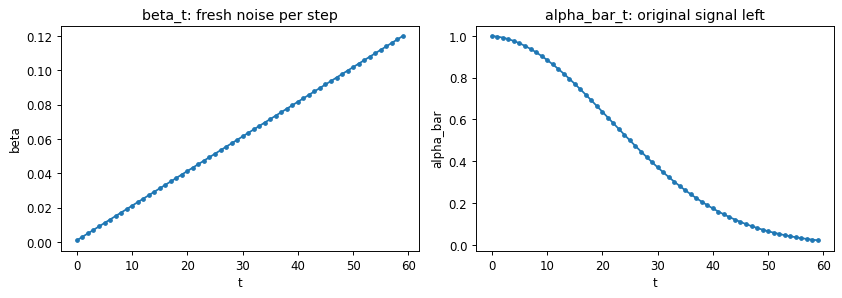

In [10]:
T = 60
beta = np.linspace(0.001, 0.12, T)
alpha = 1.0 - beta
alpha_bar = np.cumprod(alpha)

log("T steps", T)
log("beta first/middle/last", np.round([beta[0], beta[T//2], beta[-1]], 4).tolist())
log("alpha_bar first/middle/last", np.round([alpha_bar[0], alpha_bar[T//2], alpha_bar[-1]], 5).tolist())
log("signal left at final step", f"{100*alpha_bar[-1]:.2f}%")
assert np.all(np.diff(alpha_bar) < 0)

fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
ax[0].plot(beta, "-o", markersize=3); ax[0].set_title("beta_t: fresh noise per step")
ax[0].set_xlabel("t"); ax[0].set_ylabel("beta")
ax[1].plot(alpha_bar, "-o", markersize=3); ax[1].set_title("alpha_bar_t: original signal left")
ax[1].set_xlabel("t"); ax[1].set_ylabel("alpha_bar")
plt.tight_layout(); plt.show()

## Forward process · Toy example: watch points become noise

We apply the closed form to the same data at several times. Early pictures still show two blobs;
late pictures should look like almost standard normal noise.

[raw data] mean=[-0.028, -0.002] var=2.099
[t=5] alpha_bar=0.96425 mean=[-0.025, -0.013] var=2.096
[t=20] alpha_bar=0.63701 mean=[-0.015, -0.039] var=1.770
[t=40] alpha_bar=0.17488 mean=[-0.0, -0.057] var=1.201
[t=59] alpha_bar=0.02269 mean=[0.008, -0.061] var=0.972
[x_T overall variance] 0.972


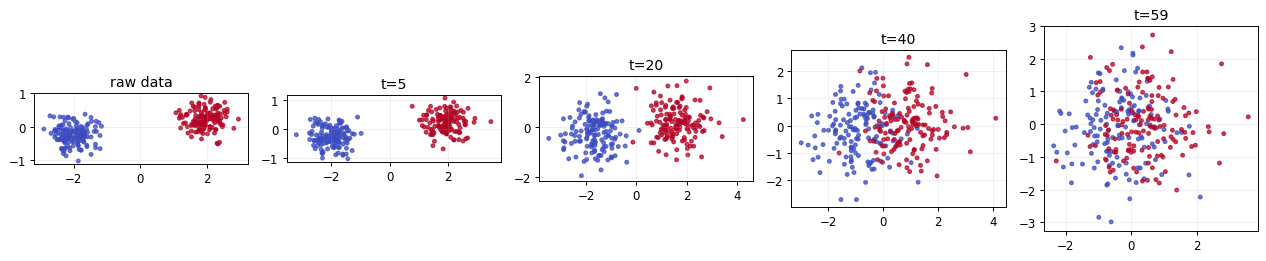

In [12]:
def q_sample_batch(x0, t, eps=None):
    t = np.asarray(t, dtype=int)
    if eps is None:
        eps = np.random.normal(size=x0.shape)
    ab = alpha_bar[t][:, None]
    return np.sqrt(ab) * x0 + np.sqrt(1.0 - ab) * eps, eps

fixed_eps = np.random.normal(size=X.shape)
times = [None, 5, 20, 40, 59]
names = ["raw data", "t=5", "t=20", "t=40", "t=59"]
fig, ax = plt.subplots(1, len(times), figsize=(15, 3.0))
for j, (name, t) in enumerate(zip(names, times)):
    if t is None:
        pts = X
        log(name, f"mean={np.round(pts.mean(axis=0),3).tolist()} var={pts.var():.3f}")
    else:
        pts, _ = q_sample_batch(X, np.full(len(X), t), fixed_eps)
        log(name, f"alpha_bar={alpha_bar[t]:.5f} mean={np.round(pts.mean(axis=0),3).tolist()} var={pts.var():.3f}")
    ax[j].scatter(pts[:,0], pts[:,1], c=y, cmap="coolwarm", s=10, alpha=0.75)
    ax[j].set_title(name); equal_axes(ax[j])
x_T, _ = q_sample_batch(X, np.full(len(X), T-1), fixed_eps)
log("x_T overall variance", round(float(x_T.var()), 3))
assert abs(float(x_T.var()) - 1.0) < 0.35
plt.tight_layout(); plt.show()

## Forward process · Toy example: one point, one noise vector

For one original point, we reuse one fixed noise vector. This lets you see exactly how the formula
slides from data toward noise as `t` grows.

[t=0] sqrt(alpha_bar)=0.999, sqrt(1-alpha_bar)=0.032, x_t=[-1.35, -0.162]
[t=15] sqrt(alpha_bar)=0.878, sqrt(1-alpha_bar)=0.479, x_t=[-0.734, -0.48]
[t=30] sqrt(alpha_bar)=0.610, sqrt(1-alpha_bar)=0.793, x_t=[-0.05, -0.679]
[t=45] sqrt(alpha_bar)=0.332, sqrt(1-alpha_bar)=0.943, x_t=[0.484, -0.753]
[t=59] sqrt(alpha_bar)=0.151, sqrt(1-alpha_bar)=0.989, x_t=[0.78, -0.762]


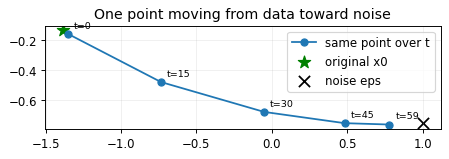

In [14]:
point = X[[0]]
eps_one = np.array([[1.0, -0.75]])
trace_t = [0, 15, 30, 45, 59]
trace = []
for t in trace_t:
    xt, _ = q_sample_batch(point, np.array([t]), eps_one)
    signal_weight = float(np.sqrt(alpha_bar[t]))
    noise_weight = float(np.sqrt(1 - alpha_bar[t]))
    log(f"t={t}", f"sqrt(alpha_bar)={signal_weight:.3f}, sqrt(1-alpha_bar)={noise_weight:.3f}, x_t={np.round(xt[0],3).tolist()}")
    trace.append(xt[0])
trace = np.array(trace)

plt.plot(trace[:,0], trace[:,1], "-o", label="same point over t")
plt.scatter(point[:,0], point[:,1], c="green", s=120, marker="*", label="original x0")
plt.scatter(eps_one[:,0], eps_one[:,1], c="black", s=90, marker="x", label="noise eps")
for t, p in zip(trace_t, trace):
    plt.text(p[0]+0.04, p[1]+0.04, f"t={t}", fontsize=8)
plt.title("One point moving from data toward noise")
plt.legend(); equal_axes(plt.gca()); plt.show()

---
# Part C · The training target: predict epsilon (the noise)

## Epsilon prediction · Toy example

The denoiser receives `(x_t, t)` and predicts **epsilon**, the exact noise that was mixed in. This
is called **epsilon prediction**.

Why predict noise? If the model knows the noise, it can subtract it out and recover an estimate of
the clean point.

**Good for:** a stable supervised target: "what noise was added?"

**Watch out for:** the model must know `t`; a tiny amount of noise and a huge amount of noise need
different denoising behavior.

[training input features shape] (3200, 5)
[training target eps shape] (3200, 2)
[one feature row [x_t0,x_t1,t,sin,cos]] [2.328, 0.042, 0.051, 0.159, 0.987]
[one target eps row] [0.413, -1.083]


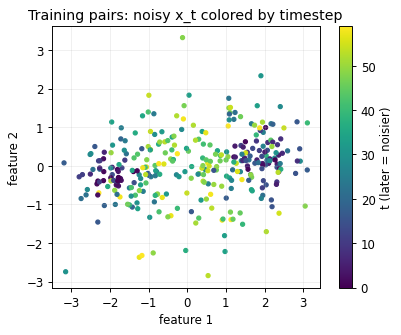

In [16]:
def time_embed(t):
    u = np.asarray(t, dtype=float).reshape(-1, 1) / (T - 1)
    return np.hstack([u, np.sin(np.pi*u), np.cos(np.pi*u)])

def make_uncond_features(x, t):
    return np.hstack([x, time_embed(t)])

N_train = 3200
idx = np.random.randint(0, len(X), size=N_train)
t_train = np.random.randint(0, T, size=N_train)
eps_train = np.random.normal(size=(N_train, 2))
x_train_noisy, eps_target = q_sample_batch(X[idx], t_train, eps_train)
F_train = make_uncond_features(x_train_noisy, t_train)

log("training input features shape", F_train.shape)
log("training target eps shape", eps_target.shape)
log("one feature row [x_t0,x_t1,t,sin,cos]", np.round(F_train[0], 3).tolist())
log("one target eps row", np.round(eps_target[0], 3).tolist())

take = np.arange(0, N_train, 10)
plt.scatter(x_train_noisy[take,0], x_train_noisy[take,1], c=t_train[take], cmap="viridis", s=12)
plt.colorbar(label="t (later = noisier)")
plt.title("Training pairs: noisy x_t colored by timestep")
plt.xlabel("feature 1"); plt.ylabel("feature 2"); equal_axes(plt.gca()); plt.show()

## Epsilon prediction · Toy example: noise ↔ clean data

The same closed form can be rearranged:

`x0_hat = (x_t - sqrt(1-alpha_bar_t) * eps_hat) / sqrt(alpha_bar_t)`

So predicting `eps` is equivalent to predicting a denoised `x0`.

[timesteps used] [3, 15, 38, 46, 52, 30, 6, 29]
[max recovery error using TRUE eps] 0.000000000000
[first original/noisy/recovered] {'x0': [2.295, 0.18], 'xt': [2.328, 0.042], 'recovered': [2.295, 0.18]}


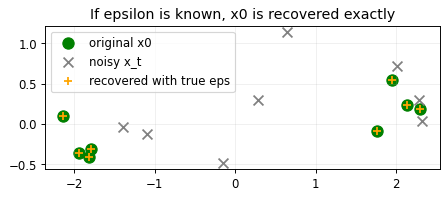

In [18]:
small = np.arange(8)
x0_small = X[idx[small]]
t_small = t_train[small]
eps_small = eps_train[small]
xt_small, _ = q_sample_batch(x0_small, t_small, eps_small)
ab = alpha_bar[t_small][:, None]
x0_recovered = (xt_small - np.sqrt(1-ab) * eps_small) / np.sqrt(ab)
max_err = float(np.abs(x0_recovered - x0_small).max())

log("timesteps used", t_small.tolist())
log("max recovery error using TRUE eps", f"{max_err:.12f}")
log("first original/noisy/recovered", {
    "x0": np.round(x0_small[0], 3).tolist(),
    "xt": np.round(xt_small[0], 3).tolist(),
    "recovered": np.round(x0_recovered[0], 3).tolist()
})
assert max_err < 1e-10

plt.scatter(x0_small[:,0], x0_small[:,1], c="green", s=90, marker="o", label="original x0")
plt.scatter(xt_small[:,0], xt_small[:,1], c="gray", s=70, marker="x", label="noisy x_t")
plt.scatter(x0_recovered[:,0], x0_recovered[:,1], c="orange", s=40, marker="+", label="recovered with true eps")
plt.title("If epsilon is known, x0 is recovered exactly")
plt.legend(); equal_axes(plt.gca()); plt.show()

## Time matters · Toy example

The same coordinate value can mean different things at different timesteps. That is why `t` is part
of the model input.

[t=0 weights] signal=0.999, noise=0.032
[t=10 weights] signal=0.940, noise=0.340
[t=25 weights] signal=0.707, noise=0.707
[t=40 weights] signal=0.418, noise=0.908
[t=59 weights] signal=0.151, noise=0.989


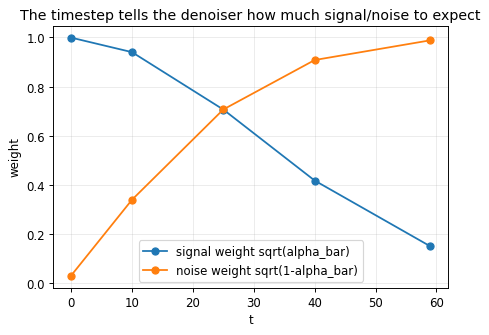

In [20]:
show_t = np.array([0, 10, 25, 40, 59])
signal = np.sqrt(alpha_bar[show_t])
noise = np.sqrt(1 - alpha_bar[show_t])
for t, s, n in zip(show_t, signal, noise):
    log(f"t={int(t)} weights", f"signal={s:.3f}, noise={n:.3f}")

plt.plot(show_t, signal, "o-", label="signal weight sqrt(alpha_bar)")
plt.plot(show_t, noise, "o-", label="noise weight sqrt(1-alpha_bar)")
plt.title("The timestep tells the denoiser how much signal/noise to expect")
plt.xlabel("t"); plt.ylabel("weight"); plt.legend(); plt.grid(True, alpha=0.25); plt.show()

---
# Part D · Train a tiny denoiser

## Tiny MLP denoiser · Toy example

We train a small **MLPRegressor** (a multilayer perceptron: a tiny neural network) to map
`[x_t, t features] → epsilon`.

**Good for:** showing the learning problem without GPUs or big libraries.

**Watch out for:** this toy MLP is much smaller than real diffusion denoisers, so samples are
imperfect but should learn the broad two-blob structure.

[MLP iterations] 220
[initial loss] 0.2955
[final loss] 0.131
[loss improvement] 0.1645


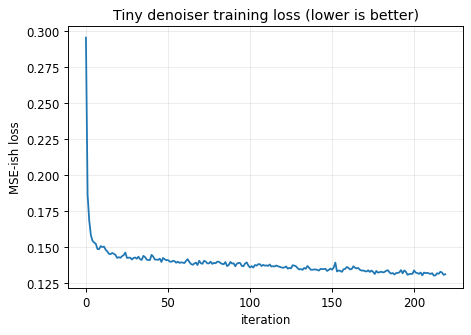

In [22]:
denoiser = MLPRegressor(hidden_layer_sizes=(64, 64), activation="relu",
                        learning_rate_init=0.003, alpha=1e-4, batch_size=128,
                        max_iter=220, random_state=0, n_iter_no_change=30, tol=1e-5)
denoiser.fit(F_train, eps_target)
losses = np.array(denoiser.loss_curve_)

log("MLP iterations", int(denoiser.n_iter_))
log("initial loss", round(float(losses[0]), 4))
log("final loss", round(float(losses[-1]), 4))
log("loss improvement", round(float(losses[0] - losses[-1]), 4))
assert losses[-1] < losses[0]

plt.plot(losses, "-")
plt.title("Tiny denoiser training loss (lower is better)")
plt.xlabel("iteration"); plt.ylabel("MSE-ish loss"); plt.grid(True, alpha=0.25); plt.show()

## Tiny MLP denoiser · Toy example: denoise a noisy batch

Now we ask the trained model to predict noise at one timestep, convert that prediction into
`x0_hat`, and compare it with the original clean points.

[noisy vs clean MSE] 1.1453
[denoised vs clean MSE] 0.7641
[first predicted eps] [-0.19, 0.517]


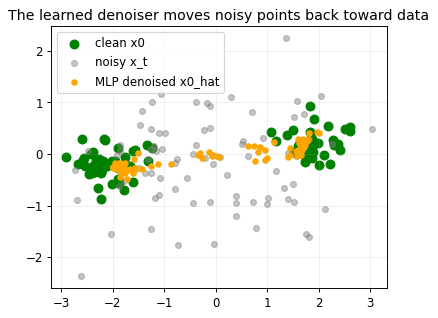

In [24]:
check_idx = np.random.choice(len(X), size=80, replace=False)
t_check = np.full(len(check_idx), 35)
eps_check = np.random.normal(size=(len(check_idx), 2))
x_check, _ = q_sample_batch(X[check_idx], t_check, eps_check)
eps_hat = denoiser.predict(make_uncond_features(x_check, t_check))
ab = alpha_bar[t_check][:, None]
x0_hat = (x_check - np.sqrt(1-ab) * eps_hat) / np.sqrt(ab)

noisy_mse = float(np.mean((x_check - X[check_idx])**2))
denoised_mse = float(np.mean((x0_hat - X[check_idx])**2))
log("noisy vs clean MSE", round(noisy_mse, 4))
log("denoised vs clean MSE", round(denoised_mse, 4))
log("first predicted eps", np.round(eps_hat[0], 3).tolist())
assert denoised_mse < noisy_mse

plt.scatter(X[check_idx,0], X[check_idx,1], c="green", s=55, label="clean x0")
plt.scatter(x_check[:,0], x_check[:,1], c="gray", s=25, alpha=0.45, label="noisy x_t")
plt.scatter(x0_hat[:,0], x0_hat[:,1], c="orange", s=20, label="MLP denoised x0_hat")
plt.title("The learned denoiser moves noisy points back toward data")
plt.legend(); equal_axes(plt.gca()); plt.show()

## Tiny MLP denoiser · Toy example: a denoising vector field

A **vector field** is a picture of arrows. Here each arrow points from a noisy location toward the
model's estimated cleaner location.

[field timestep] 35
[first grid point] [-3.2, -2.2]
[first arrow dx,dy] [1.238, 1.918]
[median arrow length] 1.385


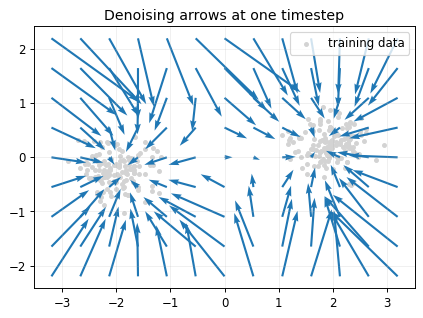

In [26]:
t_field = 35
gx, gy = np.meshgrid(np.linspace(-3.2, 3.2, 13), np.linspace(-2.2, 2.2, 9))
grid = np.column_stack([gx.ravel(), gy.ravel()])
eps_grid = denoiser.predict(make_uncond_features(grid, np.full(len(grid), t_field)))
ab = alpha_bar[t_field]
x0_grid = (grid - np.sqrt(1-ab) * eps_grid) / np.sqrt(ab)
arrows = x0_grid - grid

log("field timestep", t_field)
log("first grid point", np.round(grid[0], 3).tolist())
log("first arrow dx,dy", np.round(arrows[0], 3).tolist())
log("median arrow length", round(float(np.median(np.linalg.norm(arrows, axis=1))), 3))

plt.scatter(X[:,0], X[:,1], c="lightgray", s=10, label="training data")
plt.quiver(grid[:,0], grid[:,1], arrows[:,0], arrows[:,1], angles="xy", scale_units="xy", scale=1.8, color="tab:blue")
plt.title("Denoising arrows at one timestep")
plt.legend(); equal_axes(plt.gca()); plt.show()

---
# Part E · Reverse sampling: noise → new data

## Reverse process · Toy example: one DDPM-style step

During sampling, we start at `x_T ~ N(0, I)` and walk backward. A simplified DDPM-style update uses
the predicted noise to compute a mean for the previous step, then adds a tiny bit of fresh noise
unless we are at the final step.

**Good for:** generating new samples, not just cleaning existing ones.

**Watch out for:** each step depends on the previous step, so bad predictions can compound.

[reverse demo timestep] 45
[alpha, beta, alpha_bar] [0.90824, 0.09176, 0.1105]
[noise scale for this step] 0.3029
[first x_t] [2.016, -0.298]
[first predicted eps] [1.604, -0.389]
[first mean for x_(t-1)] [1.952, -0.273]


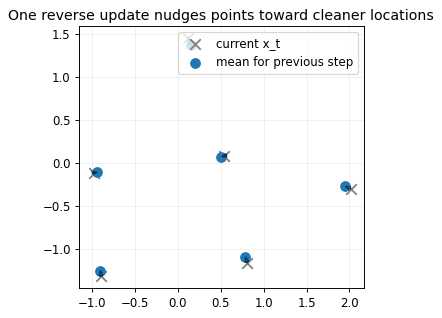

In [28]:
t_demo = 45
x_demo = np.random.normal(size=(6, 2))
eps_demo = denoiser.predict(make_uncond_features(x_demo, np.full(len(x_demo), t_demo)))
a = alpha[t_demo]; b = beta[t_demo]; ab = alpha_bar[t_demo]
mean_demo = (x_demo - (b / np.sqrt(1-ab)) * eps_demo) / np.sqrt(a)
noise_scale = np.sqrt(b)

log("reverse demo timestep", t_demo)
log("alpha, beta, alpha_bar", np.round([a, b, ab], 5).tolist())
log("noise scale for this step", round(float(noise_scale), 4))
log("first x_t", np.round(x_demo[0], 3).tolist())
log("first predicted eps", np.round(eps_demo[0], 3).tolist())
log("first mean for x_(t-1)", np.round(mean_demo[0], 3).tolist())

plt.scatter(x_demo[:,0], x_demo[:,1], c="gray", marker="x", s=80, label="current x_t")
plt.scatter(mean_demo[:,0], mean_demo[:,1], c="tab:blue", s=65, label="mean for previous step")
for p, q in zip(x_demo, mean_demo):
    plt.arrow(p[0], p[1], q[0]-p[0], q[1]-p[1], head_width=0.04, length_includes_head=True, alpha=0.6)
plt.title("One reverse update nudges points toward cleaner locations")
plt.legend(); equal_axes(plt.gca()); plt.show()

## Reverse process · Toy example: sample step by step

Now we repeat the reverse update from `t=59` down to `t=0`. The pictures show the same generated
points at a few moments in the reverse chain.

[snapshot t=59] mean=[-0.001, -0.08] std=[1.046, 1.025]
[snapshot t=45] mean=[0.03, -0.193] std=[1.065, 1.024]
[snapshot t=30] mean=[-0.021, 0.036] std=[1.305, 0.854]
[snapshot t=15] mean=[-0.055, 0.053] std=[1.767, 0.584]
[snapshot t=0] mean=[-0.052, -0.018] std=[1.938, 0.371]


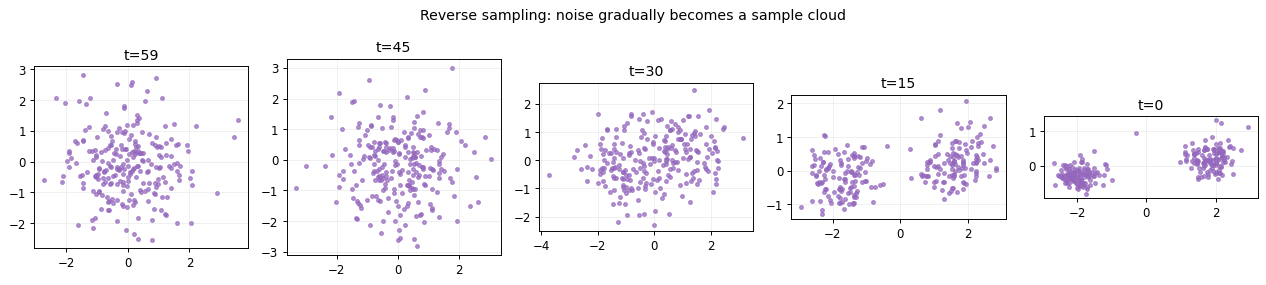

In [30]:
def sample_unconditional(model, n=220, seed=1, keep=(59, 45, 30, 15, 0)):
    rng = np.random.RandomState(seed)
    x = rng.normal(size=(n, 2))
    snapshots = {T-1: x.copy()}
    for t in reversed(range(T)):
        t_vec = np.full(n, t)
        eps_pred = model.predict(make_uncond_features(x, t_vec))
        a = alpha[t]; b = beta[t]; ab = alpha_bar[t]
        mean = (x - (b / np.sqrt(1-ab)) * eps_pred) / np.sqrt(a)
        if t > 0:
            x = mean + np.sqrt(b) * rng.normal(size=x.shape)
        else:
            x = mean
        if t in keep:
            snapshots[t] = x.copy()
    return x, snapshots

generated, gen_snaps = sample_unconditional(denoiser, n=240, seed=2)
for t in [59, 45, 30, 15, 0]:
    pts = gen_snaps[t]
    log(f"snapshot t={t}", f"mean={np.round(pts.mean(axis=0),3).tolist()} std={np.round(pts.std(axis=0),3).tolist()}")

fig, ax = plt.subplots(1, 5, figsize=(15, 3.0))
for j, t in enumerate([59, 45, 30, 15, 0]):
    pts = gen_snaps[t]
    ax[j].scatter(pts[:,0], pts[:,1], c="tab:purple", s=10, alpha=0.7)
    ax[j].set_title(f"t={t}"); equal_axes(ax[j])
plt.suptitle("Reverse sampling: noise gradually becomes a sample cloud", y=1.03)
plt.tight_layout(); plt.show()

## Reverse process · Toy example: generated cloud vs original cloud

The generated points should not match the training points exactly, but the cloud should land near
the same overall region and broad shape.

[real mean] [-0.028, -0.002]
[generated mean] [-0.052, -0.018]
[mean gap] 0.029
[real std] [2.017, 0.363]
[generated std] [1.938, 0.371]
[shape gap] 0.079


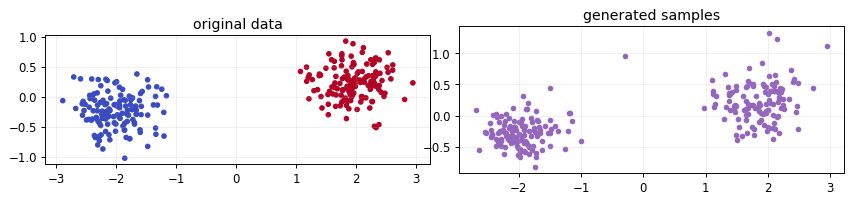

In [32]:
real_mean = X.mean(axis=0)
gen_mean = generated.mean(axis=0)
real_std = X.std(axis=0)
gen_std = generated.std(axis=0)
mean_gap = float(np.linalg.norm(gen_mean - real_mean))
shape_gap = float(np.linalg.norm(gen_std - real_std))

log("real mean", np.round(real_mean, 3).tolist())
log("generated mean", np.round(gen_mean, 3).tolist())
log("mean gap", round(mean_gap, 3))
log("real std", np.round(real_std, 3).tolist())
log("generated std", np.round(gen_std, 3).tolist())
log("shape gap", round(shape_gap, 3))
assert mean_gap < 0.90
assert shape_gap < 1.80

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].scatter(X[:,0], X[:,1], c=y, cmap="coolwarm", s=14); ax[0].set_title("original data")
ax[1].scatter(generated[:,0], generated[:,1], c="tab:purple", s=14); ax[1].set_title("generated samples")
for axt in ax:
    equal_axes(axt)
plt.tight_layout(); plt.show()

---
# Part F · Conditioning: ask for a class

## Conditioning · Toy example

**Conditioning** means giving the denoiser extra information about what you want. In this toy, the
condition is a class label: "make class 0" or "make class 1." In real text-to-image systems, the
condition is often a text prompt.

**Good for:** controllable generation.

**Watch out for:** the model can ignore weak conditions or overfit strong ones.

[class 0 center] [-2.013, -0.236]
[class 1 center] [1.956, 0.233]
[label 0 embedding] [1, 0, 0]
[label 1 embedding] [0, 1, 0]
[dropped-label embedding] [0, 0, 1]


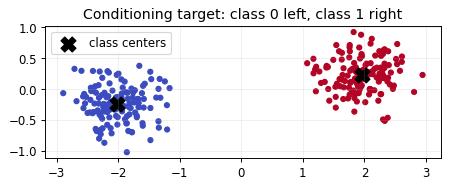

In [34]:
def label_embed(labels):
    labels = np.asarray(labels)
    out = np.zeros((len(labels), 3))
    out[labels == 0, 0] = 1.0
    out[labels == 1, 1] = 1.0
    out[labels < 0, 2] = 1.0
    return out

def make_cond_features(x, t, labels):
    return np.hstack([x, time_embed(t), label_embed(labels)])

centers = np.vstack([X[y == 0].mean(axis=0), X[y == 1].mean(axis=0)])
log("class 0 center", np.round(centers[0], 3).tolist())
log("class 1 center", np.round(centers[1], 3).tolist())
log("label 0 embedding", label_embed([0]).astype(int).tolist()[0])
log("label 1 embedding", label_embed([1]).astype(int).tolist()[0])
log("dropped-label embedding", label_embed([-1]).astype(int).tolist()[0])

plt.scatter(X[:,0], X[:,1], c=y, cmap="coolwarm", s=18)
plt.scatter(centers[:,0], centers[:,1], c="black", marker="X", s=160, label="class centers")
plt.title("Conditioning target: class 0 left, class 1 right")
plt.legend(); equal_axes(plt.gca()); plt.show()

## Conditioning · Toy example: train with labels, sometimes dropped

For **classifier-free guidance**, we train one model that can work two ways:

- Conditional: label is present (`class 0` or `class 1`).
- Unconditional: label is dropped (we use a special "missing label" input).

Dropping labels during training teaches the same model both behaviors.

[conditional feature shape] (4800, 8)
[dropped-label training rows] 897
[conditional initial loss] 0.2372
[conditional final loss] 0.108


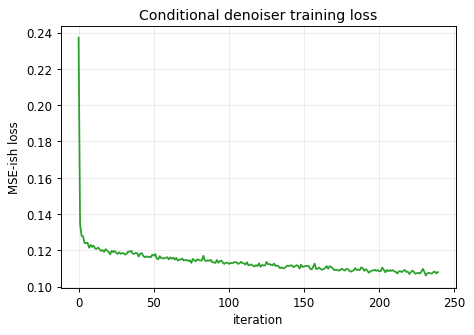

In [36]:
N_cond = 4800
idx_c = np.random.randint(0, len(X), size=N_cond)
t_cond = np.random.randint(0, T, size=N_cond)
eps_cond = np.random.normal(size=(N_cond, 2))
x_cond_noisy, eps_cond_target = q_sample_batch(X[idx_c], t_cond, eps_cond)
labels_in = y[idx_c].copy()
drop_mask = np.random.rand(N_cond) < 0.18
labels_in[drop_mask] = -1
F_cond = make_cond_features(x_cond_noisy, t_cond, labels_in)

cond_denoiser = MLPRegressor(hidden_layer_sizes=(64, 64), activation="relu",
                             learning_rate_init=0.003, alpha=1e-4, batch_size=128,
                             max_iter=240, random_state=1, n_iter_no_change=35, tol=1e-5)
cond_denoiser.fit(F_cond, eps_cond_target)
cond_losses = np.array(cond_denoiser.loss_curve_)

log("conditional feature shape", F_cond.shape)
log("dropped-label training rows", int(drop_mask.sum()))
log("conditional initial loss", round(float(cond_losses[0]), 4))
log("conditional final loss", round(float(cond_losses[-1]), 4))
assert cond_losses[-1] < cond_losses[0]

plt.plot(cond_losses, color="tab:green")
plt.title("Conditional denoiser training loss")
plt.xlabel("iteration"); plt.ylabel("MSE-ish loss"); plt.grid(True, alpha=0.25); plt.show()

## Conditioning · Toy example: generate class 0 vs class 1

At sampling time we feed the requested label every step. Class 0 samples should land on the left;
class 1 samples should land on the right.

[generated class 0 mean] [-2.024, -0.216]
[generated class 1 mean] [1.943, 0.2]
[requested-class center distance] {'class0': 0.023, 'class1': 0.035}


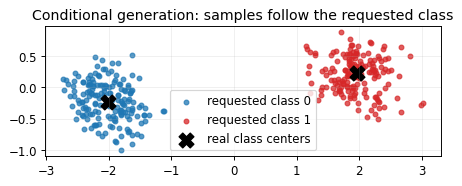

In [38]:
def predict_eps_cfg(model, x, t, label, w):
    t_vec = np.full(len(x), t)
    cond_labels = np.full(len(x), label)
    miss_labels = np.full(len(x), -1)
    eps_uncond = model.predict(make_cond_features(x, t_vec, miss_labels))
    eps_cond = model.predict(make_cond_features(x, t_vec, cond_labels))
    return eps_uncond + w * (eps_cond - eps_uncond)

def sample_conditional(label, n=160, guidance_w=1.0, seed=10):
    rng = np.random.RandomState(seed)
    x = rng.normal(size=(n, 2))
    for t in reversed(range(T)):
        eps_pred = predict_eps_cfg(cond_denoiser, x, t, label, guidance_w)
        a = alpha[t]; b = beta[t]; ab = alpha_bar[t]
        mean = (x - (b / np.sqrt(1-ab)) * eps_pred) / np.sqrt(a)
        if t > 0:
            x = mean + np.sqrt(b) * rng.normal(size=x.shape)
        else:
            x = mean
    return x

gen_c0 = sample_conditional(0, n=170, guidance_w=1.2, seed=30)
gen_c1 = sample_conditional(1, n=170, guidance_w=1.2, seed=31)
log("generated class 0 mean", np.round(gen_c0.mean(axis=0), 3).tolist())
log("generated class 1 mean", np.round(gen_c1.mean(axis=0), 3).tolist())
log("requested-class center distance", {
    "class0": round(float(np.linalg.norm(gen_c0.mean(axis=0) - centers[0])), 3),
    "class1": round(float(np.linalg.norm(gen_c1.mean(axis=0) - centers[1])), 3)
})
assert gen_c0.mean(axis=0)[0] < -0.25
assert gen_c1.mean(axis=0)[0] > 0.25

plt.scatter(gen_c0[:,0], gen_c0[:,1], c="tab:blue", s=16, alpha=0.75, label="requested class 0")
plt.scatter(gen_c1[:,0], gen_c1[:,1], c="tab:red", s=16, alpha=0.75, label="requested class 1")
plt.scatter(centers[:,0], centers[:,1], c="black", marker="X", s=160, label="real class centers")
plt.title("Conditional generation: samples follow the requested class")
plt.legend(); equal_axes(plt.gca()); plt.show()

---
# Part G · Classifier-free guidance: turn up the prompt strength

## Classifier-free guidance · Toy example

**Classifier-free guidance** combines two predictions from the same model:

`guided eps = eps_uncond + w * (eps_cond - eps_uncond)`

- `eps_uncond`: prediction with no label/prompt.
- `eps_cond`: prediction with the label/prompt.
- `w`: guidance weight. Higher `w` pushes harder toward the condition.

**Good for:** stronger prompt following.

**Watch out for:** too much guidance can reduce diversity or overshoot into strange samples.

[w=0 guided eps] [0.245, 0.056]
[w=1 guided eps] [-1.076, -0.124]
[w=3 guided eps] [-3.719, -0.484]
[conditional minus unconditional] [-1.321, -0.18]


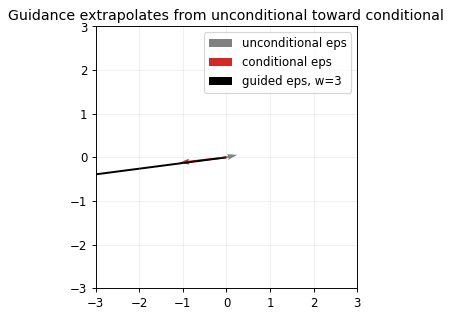

In [40]:
x_guided_demo = np.array([[0.0, 0.0]])
t_guided_demo = 35
eps_un = cond_denoiser.predict(make_cond_features(x_guided_demo, [t_guided_demo], [-1]))[0]
eps_co = cond_denoiser.predict(make_cond_features(x_guided_demo, [t_guided_demo], [1]))[0]
for w in [0, 1, 3]:
    eps_g = eps_un + w * (eps_co - eps_un)
    log(f"w={w} guided eps", np.round(eps_g, 3).tolist())
log("conditional minus unconditional", np.round(eps_co - eps_un, 3).tolist())

origin = np.array([0, 0])
plt.quiver(*origin, *eps_un, angles="xy", scale_units="xy", scale=1, color="gray", label="unconditional eps")
plt.quiver(*origin, *eps_co, angles="xy", scale_units="xy", scale=1, color="tab:red", label="conditional eps")
eps_w3 = eps_un + 3 * (eps_co - eps_un)
plt.quiver(*origin, *eps_w3, angles="xy", scale_units="xy", scale=1, color="black", label="guided eps, w=3")
plt.xlim(-3, 3); plt.ylim(-3, 3); plt.title("Guidance extrapolates from unconditional toward conditional")
plt.legend(); equal_axes(plt.gca()); plt.show()

## Classifier-free guidance · Toy example: compare w = 0, 1, 3

We generate both classes at several guidance weights. Higher guidance should separate the requested
classes more strongly, often making samples tighter and less diverse.

[w=0.0] class separation=0.057, average spread=1.708
[w=1.0] class separation=3.814, average spread=0.412
[w=3.0] class separation=4.628, average spread=0.490


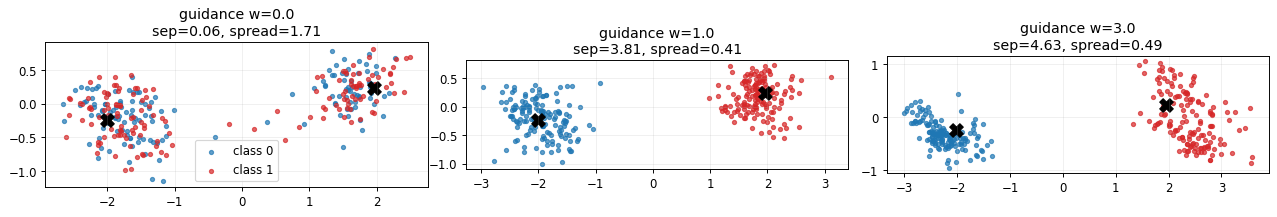

In [42]:
guidance_weights = [0.0, 1.0, 3.0]
guidance_results = {}
for w in guidance_weights:
    a0 = sample_conditional(0, n=150, guidance_w=w, seed=100 + int(10*w))
    a1 = sample_conditional(1, n=150, guidance_w=w, seed=101 + int(10*w))
    sep = float(np.linalg.norm(a1.mean(axis=0) - a0.mean(axis=0)))
    spread0 = float(np.mean(np.linalg.norm(a0 - a0.mean(axis=0), axis=1)))
    spread1 = float(np.mean(np.linalg.norm(a1 - a1.mean(axis=0), axis=1)))
    spread = 0.5 * (spread0 + spread1)
    guidance_results[w] = {"c0": a0, "c1": a1, "sep": sep, "spread": spread}
    log(f"w={w}", f"class separation={sep:.3f}, average spread={spread:.3f}")

assert guidance_results[3.0]["sep"] > guidance_results[0.0]["sep"] + 0.30

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for j, w in enumerate(guidance_weights):
    a0 = guidance_results[w]["c0"]; a1 = guidance_results[w]["c1"]
    ax[j].scatter(a0[:,0], a0[:,1], c="tab:blue", s=12, alpha=0.7, label="class 0")
    ax[j].scatter(a1[:,0], a1[:,1], c="tab:red", s=12, alpha=0.7, label="class 1")
    ax[j].scatter(centers[:,0], centers[:,1], c="black", marker="X", s=130)
    ax[j].set_title(f"guidance w={w}\nsep={guidance_results[w]['sep']:.2f}, spread={guidance_results[w]['spread']:.2f}")
    equal_axes(ax[j])
ax[0].legend()
plt.tight_layout(); plt.show()

## Guidance tradeoff · Toy example: fidelity vs diversity

**Fidelity** means "matches the requested class/prompt." **Diversity** means "many different-looking
samples." Guidance often improves fidelity but can reduce diversity.

[w=0.0 tradeoff row] fidelity proxy separation=0.057; diversity proxy spread=1.708
[w=1.0 tradeoff row] fidelity proxy separation=3.814; diversity proxy spread=0.412
[w=3.0 tradeoff row] fidelity proxy separation=4.628; diversity proxy spread=0.490


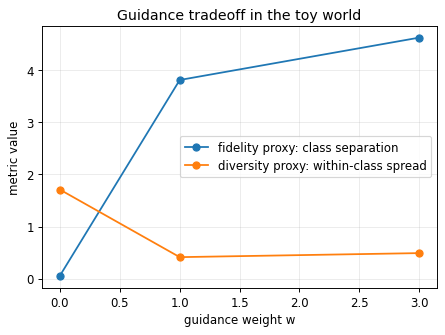

In [44]:
seps = [guidance_results[w]["sep"] for w in guidance_weights]
spreads = [guidance_results[w]["spread"] for w in guidance_weights]
for w, sep, spread in zip(guidance_weights, seps, spreads):
    log(f"w={w} tradeoff row", f"fidelity proxy separation={sep:.3f}; diversity proxy spread={spread:.3f}")

plt.plot(guidance_weights, seps, "o-", label="fidelity proxy: class separation")
plt.plot(guidance_weights, spreads, "o-", label="diversity proxy: within-class spread")
plt.title("Guidance tradeoff in the toy world")
plt.xlabel("guidance weight w"); plt.ylabel("metric value"); plt.legend(); plt.grid(True, alpha=0.25); plt.show()

---
# Part H · Real text-to-image / video systems (conceptual map)

## Real-world mapping · Toy example terms

Our toy point is a tiny stand-in for an image. In real systems:

- **Latent diffusion**: diffuse in a compressed **latent space** (a smaller learned representation),
  not directly in huge pixel space. This is faster.
- **U-Net denoiser**: a neural network shaped for images; it predicts noise at many resolutions.
- **Text encoder / CLIP-style conditioning**: turns a prompt like "a red bicycle" into vectors that
  condition the denoiser.
- **Video diffusion**: adds a time/temporal dimension, so the model must make frames that look good
  and move consistently.

**Good for:** practical high-resolution generation and prompt control.

**Watch out for:** prompts can be ambiguous; video adds temporal consistency problems; these models
can reflect biases in their training data.

[toy x_t] 2 numbers
[real latent x_t] many compressed image/video features
[toy condition] class label 0 or 1
[real condition] text prompt embedding


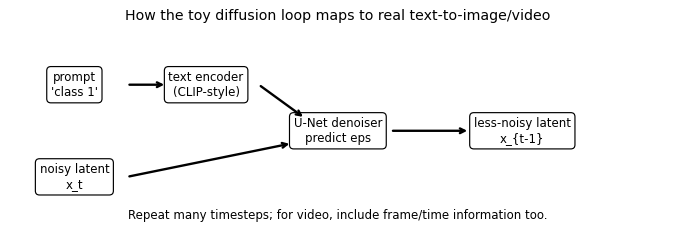

In [46]:
log("toy x_t", "2 numbers")
log("real latent x_t", "many compressed image/video features")
log("toy condition", "class label 0 or 1")
log("real condition", "text prompt embedding")

fig, ax = plt.subplots(figsize=(10, 3.2))
ax.axis("off")
items = [
    ("prompt\n'class 1'", 0.10, 0.72),
    ("text encoder\n(CLIP-style)", 0.30, 0.72),
    ("noisy latent\nx_t", 0.10, 0.28),
    ("U-Net denoiser\npredict eps", 0.50, 0.50),
    ("less-noisy latent\nx_{t-1}", 0.78, 0.50),
]
for text, x0, y0 in items:
    ax.text(x0, y0, text, ha="center", va="center",
            bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="black"))
for start, end in [((0.18,0.72),(0.24,0.72)), ((0.38,0.72),(0.45,0.56)),
                   ((0.18,0.28),(0.43,0.44)), ((0.58,0.50),(0.70,0.50))]:
    ax.annotate("", xy=end, xytext=start, arrowprops=dict(arrowstyle="->", lw=2))
ax.text(0.50, 0.08, "Repeat many timesteps; for video, include frame/time information too.", ha="center")
ax.set_title("How the toy diffusion loop maps to real text-to-image/video")
plt.show()

---
# Recap · The whole module as one chain

1. Start with data: our toy 2D points stand in for images.
2. **Forward / diffusion process:** data → add Gaussian noise with a schedule → nearly pure noise.
3. **Training target:** train an epsilon predictor, `(x_t, t) → eps`, because knowing eps lets us
   estimate the clean `x0`.
4. **Reverse / denoising process:** start from `x_T ~ N(0,I)` and iteratively denoise back to `t=0`.
5. **Conditioning:** add a label/prompt so generation can ask for a class or concept.
6. **Classifier-free guidance:** combine unconditional and conditional predictions:
   `eps_uncond + w*(eps_cond - eps_uncond)` to trade diversity for stronger prompt following.
7. **Real world:** latent diffusion uses compressed image/video latents, a U-Net denoiser, and a
   text encoder for prompts.

Final chain:

`data → (add noise, forward) → noise; train eps-predictor; noise → (iterative denoise, reverse, optionally conditioned + guided) → new sample`